In [1]:
!pip install grad-cam -q
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from PIL import Image
import timm
import cv2
import torch.nn as nn
from collections import Counter
from sklearn.metrics import (
    f1_score, accuracy_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import warnings
warnings.filterwarnings('ignore')

DATASET_PATH = "/kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 51.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    level = root.replace('/kaggle/input', '').count(os.sep)
    indent = '   ' * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    if level < 3:
        for file in files[:2]:
            print(f"{indent}   📄 {file}")

📁 input/
   📁 datasets/
      📁 gunavenkatdoddi/
         📁 eye-diseases-classification/
            📁 dataset/
               📁 glaucoma/
               📁 normal/
               📁 diabetic_retinopathy/
               📁 cataract/


In [3]:
DATASET_PATH = "/kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset"
# Vérifier
if os.path.exists(DATASET_PATH):
    print(f"Dataset trouvé : {DATASET_PATH}")
else:
    print("Dataset non trouvé")

# Les classes
classes = sorted(os.listdir(DATASET_PATH))
print(f"\nClasses trouvées ({len(classes)}) :")
for cls in classes:
    print(f"   → {cls}")

Dataset trouvé : /kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset

Classes trouvées (4) :
   → cataract
   → diabetic_retinopathy
   → glaucoma
   → normal


# 1.  **EDA**

✅ Dataset trouvé

📁 Classes (4) :
   → cataract
   → diabetic_retinopathy
   → glaucoma
   → normal

Classe                      Images        %
cataract                      1038    24.6%  ██████
diabetic_retinopathy          1098    26.0%  ██████
glaucoma                      1007    23.9%  █████
normal                        1074    25.5%  ██████
TOTAL                         4217

   Ratio max/min : 1.09×
   ✅ Dataset bien équilibré !


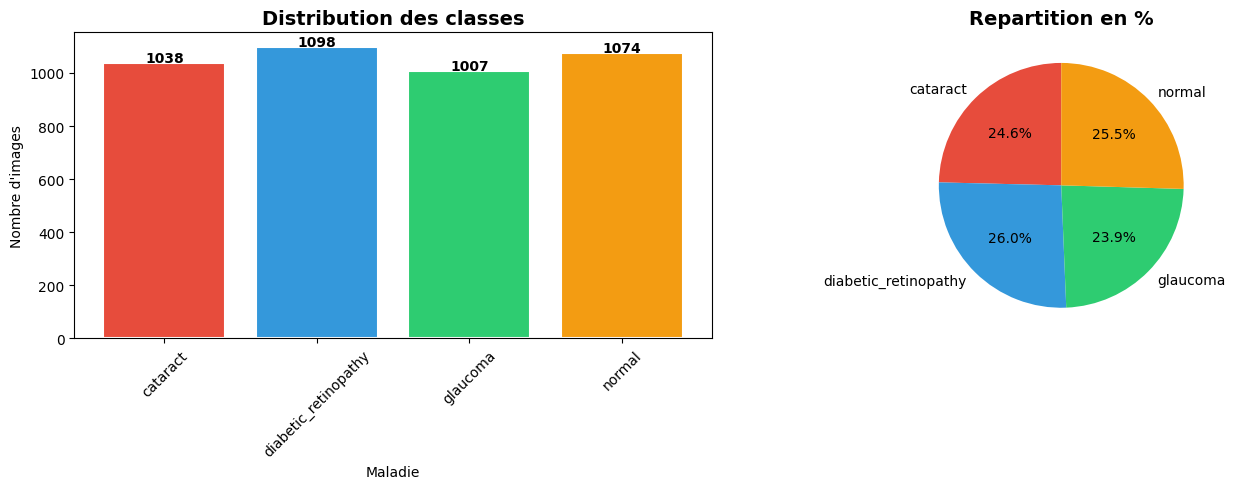

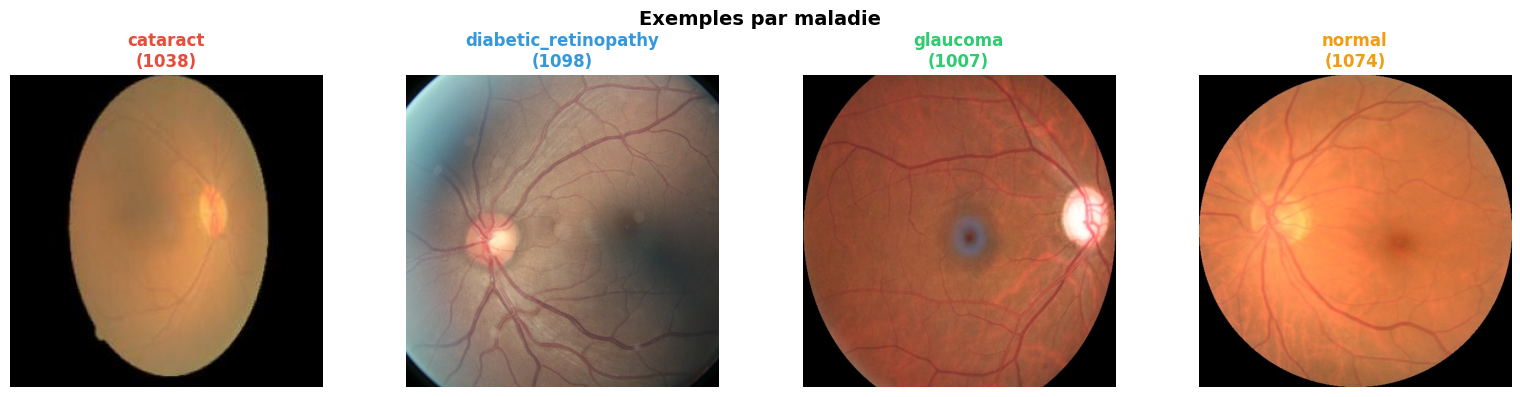


✅ Images corrompues : 0


In [4]:
# ── Vérifier ──
if os.path.exists(DATASET_PATH):
    print(f"✅ Dataset trouvé")
else:
    print("❌ Chemin incorrect")

classes = sorted(os.listdir(DATASET_PATH))
print(f"\n📁 Classes ({len(classes)}) :")
for cls in classes:
    print(f"   → {cls}")

# ── Compter images ──
class_counts = {}
total = 0

print("\n" + "=" * 50)
print(f"{'Classe':<25} {'Images':>8}   {'%':>6}")
print("=" * 50)

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    count = len([f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.png','.jpg','.jpeg'))])
    class_counts[cls] = count
    total += count

for cls, count in class_counts.items():
    pct = count / total * 100
    bar = "█" * int(pct / 4)
    print(f"{cls:<25} {count:>8}   {pct:>5.1f}%  {bar}")

print("=" * 50)
print(f"{'TOTAL':<25} {total:>8}")

# ── Déséquilibre ──
max_cls = max(class_counts, key=class_counts.get)
min_cls = min(class_counts, key=class_counts.get)
ratio   = class_counts[max_cls] / class_counts[min_cls]
print(f"\n   Ratio max/min : {ratio:.2f}×")
if ratio < 2:
    print("   ✅ Dataset bien équilibré !")
elif ratio < 5:
    print("   ⚠️  Déséquilibre modéré")
else:
    print("   ❌ Déséquilibre important")

# ── Visualisation ──
colors = ['#E74C3C','#3498DB','#2ECC71','#F39C12']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(class_counts.keys(),
                   class_counts.values(),
                   color=colors,
                   edgecolor='white',
                   linewidth=1.5)
axes[0].set_title("Distribution des classes",
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel("Maladie")
axes[0].set_ylabel("Nombre d'images")
axes[0].tick_params(axis='x', rotation=45)
for bar, count in zip(bars, class_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 str(count), ha='center',
                 fontsize=10, fontweight='bold')

axes[1].pie(class_counts.values(),
            labels=class_counts.keys(),
            colors=colors,
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title("Repartition en %",
                   fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Exemples visuels ──
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, cls in enumerate(classes):
    cls_path = os.path.join(DATASET_PATH, cls)
    img_file = os.listdir(cls_path)[0]
    img      = Image.open(os.path.join(cls_path,
                           img_file)).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(f"{cls}\n({class_counts[cls]})",
                       fontweight='bold', color=colors[i])
    axes[i].axis('off')

plt.suptitle("Exemples par maladie",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Images corrompues ──
corrupted = []
for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    for img_name in os.listdir(cls_path):
        try:
            img = Image.open(os.path.join(cls_path, img_name))
            img.verify()
        except:
            corrupted.append(img_path)

print(f"\n✅ Images corrompues : {len(corrupted)}")

In [5]:
# Reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

IMG_SIZE     = 224
BATCH_SIZE   = 16
NUM_CLASSES  = 4
EPOCHS       = 40

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print(f"IMG_SIZE : {IMG_SIZE}×{IMG_SIZE}")
print(f"BATCH_SIZE : {BATCH_SIZE}")

Device : cuda
IMG_SIZE : 224×224
BATCH_SIZE : 16


✅ CLAHE défini
✅ Transforms définis
✅ Dataset : 4217 images
✅ Classes : ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']

✅ Split stratifié :
   Train      : 2951 images (70%)
   Validation : 633 images (15%)
   Test       : 633 images (15%)

Classe                       Train      Val     Test
-------------------------------------------------------
cataract                       726      156      156
diabetic_retinopathy           768      165      165
glaucoma                       705      151      151
normal                         752      161      161
✅ DataLoaders :
   Train      : 185 batches
   Validation : 40 batches
   Test       : 40 batches
✅ Shape images : torch.Size([16, 3, 224, 224])
✅ Shape labels : torch.Size([16])


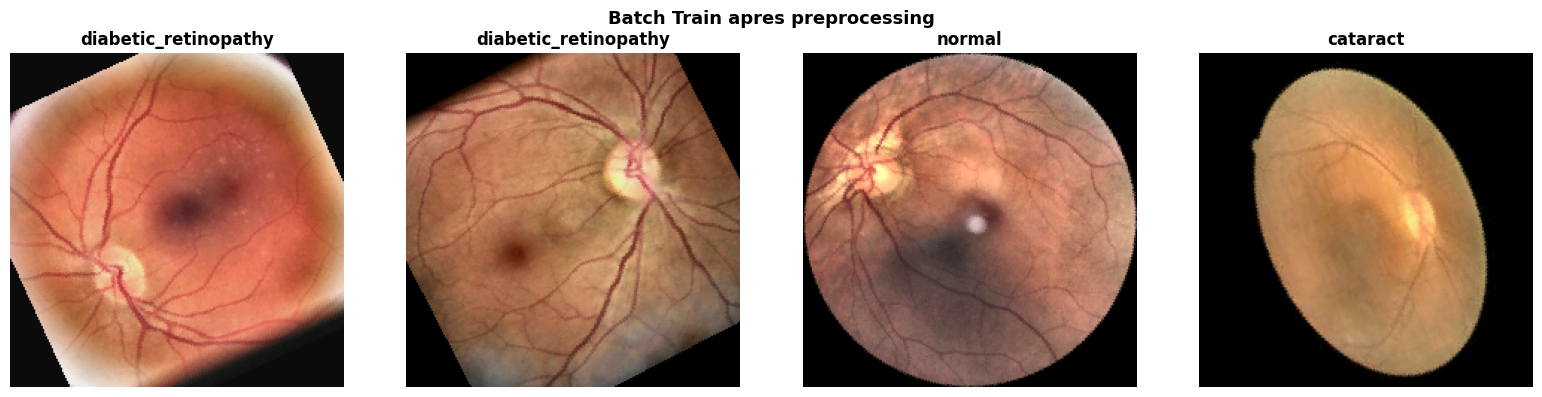

Classe                      Images   Weight
---------------------------------------------
cataract                       726    1.016
diabetic_retinopathy           768    0.961
glaucoma                       705    1.046
normal                         752    0.981

✅ Class weights : [1.016, 0.961, 1.046, 0.981]


In [6]:
# ════════════════════════════════════
# CELLULE 2 — CLAHE
# ════════════════════════════════════
def apply_clahe(image):
    img  = np.array(image)
    lab  = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0,
                              tileGridSize=(8,8))
    l    = clahe.apply(l)
    lab  = cv2.merge((l, a, b))
    result = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return Image.fromarray(result)

print("✅ CLAHE défini")

# ════════════════════════════════════
# CELLULE 3 — Transforms
# ════════════════════════════════════
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(apply_clahe),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2,
                            contrast=0.2,
                            saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(apply_clahe),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225])
])

print("✅ Transforms définis")

# ════════════════════════════════════
# CELLULE 4 — Split Stratifié
# ════════════════════════════════════
full_dataset = ImageFolder(root=DATASET_PATH,
                            transform=train_transforms)

print(f"✅ Dataset : {len(full_dataset)} images")
print(f"✅ Classes : {full_dataset.classes}")

targets = full_dataset.targets
indices = list(range(len(full_dataset)))

# Split 70/15/15
train_idx, temp_idx = train_test_split(
    indices,
    test_size   = 0.30,
    stratify    = targets,
    random_state= SEED
)
temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size   = 0.50,
    stratify    = temp_targets,
    random_state= SEED
)

print(f"\n✅ Split stratifié :")
print(f"   Train      : {len(train_idx)} images (70%)")
print(f"   Validation : {len(val_idx)} images (15%)")
print(f"   Test       : {len(test_idx)} images (15%)")

# Vérification
train_labels = [targets[i] for i in train_idx]
val_labels   = [targets[i] for i in val_idx]
test_labels  = [targets[i] for i in test_idx]
counts       = Counter(train_labels)

print(f"\n{'Classe':<25} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 55)
for i, cls in enumerate(full_dataset.classes):
    tr = Counter(train_labels)[i]
    va = Counter(val_labels)[i]
    te = Counter(test_labels)[i]
    print(f"{cls:<25} {tr:>8} {va:>8} {te:>8}")

# Subsets
train_dataset = Subset(full_dataset, train_idx)
val_full      = ImageFolder(root=DATASET_PATH,
                             transform=val_transforms)
val_dataset   = Subset(val_full, val_idx)
test_dataset  = Subset(val_full, test_idx)

# ════════════════════════════════════
# CELLULE 5 — DataLoaders
# ════════════════════════════════════
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 2,
    pin_memory  = True
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)
test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)

print(f"✅ DataLoaders :")
print(f"   Train      : {len(train_loader)} batches")
print(f"   Validation : {len(val_loader)} batches")
print(f"   Test       : {len(test_loader)} batches")

# ════════════════════════════════════
# CELLULE 6 — Vérification batch
# ════════════════════════════════════
images, labels = next(iter(train_loader))
print(f"✅ Shape images : {images.shape}")
print(f"✅ Shape labels : {labels.shape}")

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0, 1)

class_names = full_dataset.classes
fig, axes   = plt.subplots(1, 4, figsize=(16, 4))

for i in range(4):
    img = denormalize(images[i]).permute(1,2,0).numpy()
    axes[i].imshow(img)
    axes[i].set_title(class_names[labels[i]],
                       fontweight='bold')
    axes[i].axis('off')

plt.suptitle("Batch Train apres preprocessing",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ════════════════════════════════════
# CELLULE 7 — Class Weights
# ════════════════════════════════════
total_train = len(train_labels)
weights     = []

print(f"{'Classe':<25} {'Images':>8} {'Weight':>8}")
print("-" * 45)

for i in range(NUM_CLASSES):
    count  = counts[i]
    weight = total_train / (NUM_CLASSES * count)
    weights.append(weight)
    print(f"{class_names[i]:<25} {count:>8} {weight:>8.3f}")

class_weights = torch.FloatTensor(weights).to(device)
print(f"\n✅ Class weights : {[round(w,3) for w in weights]}")

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

✅ Total params    : 18,469,708
✅ Trainable params: 18,469,708
✅ Focal Loss definie
Backbone gele
Epoch 01/40 | Loss: 0.5028/0.2996 | F1: 0.6247/0.7460 | Acc: 0.6276/0.7488
  Modele sauvegarde (F1=0.7460 Acc=0.7488)
Epoch 02/40 | Loss: 0.3424/0.2587 | F1: 0.7102/0.7596 | Acc: 0.7113/0.7567
  Modele sauvegarde (F1=0.7596 Acc=0.7567)
Epoch 03/40 | Loss: 0.3394/0.2407 | F1: 0.7101/0.7677 | Acc: 0.7106/0.7725
  Modele sauvegarde (F1=0.7677 Acc=0.7725)
Epoch 04/40 | Loss: 0.3163/0.2468 | F1: 0.7160/0.7710 | Acc: 0.7167/0.7678
  Modele sauvegarde (F1=0.7710 Acc=0.7678)
Epoch 05/40 | Loss: 0.3121/0.2353 | F1: 0.7248/0.7704 | Acc: 0.7245/0.7725
Epoch 06/40 | Loss: 0.3093/0.2636 | F1: 0.7354/0.7705 | Acc: 0.7350/0.7662
Epoch 07/40 | Loss: 0.2889/0.2146 | F1: 0.7457/0.7857 | Acc: 0.7462/0.7852
  Modele sauvegarde (F1=0.7857 Acc=0.7852)
Epoch 08/40 | Loss: 0.3004/0.2328 | F1: 0.7409/0.8016 | Acc: 0.7397/0.7994
  Modele sauvegarde (F1=0.8016 Acc=0.7994)
Epoch 09/40 | Loss: 0.2876/0.2304 | F1: 0.738

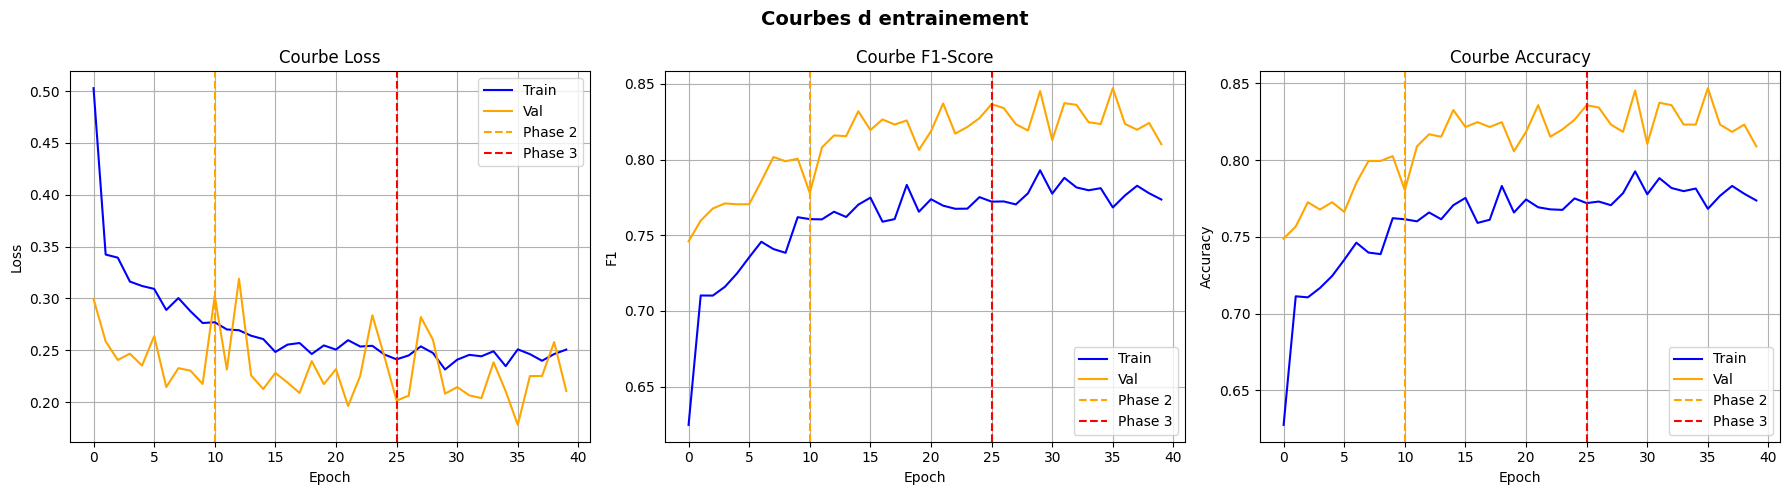

In [7]:
# ════════════════════════════════════
# CELLULE 2 — Modèle
# ════════════════════════════════════
class EyeDiseaseClassifier(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b4',
            pretrained  = pretrained,
            num_classes = 0,
            global_pool = 'avg'
        )
        in_features = self.backbone.num_features  # 1792

        self.head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.head(self.backbone(x))

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
        print("Backbone gele")

    def unfreeze_last_blocks(self, n=3):
        blocks = list(self.backbone.children())
        for block in blocks[-n:]:
            for p in block.parameters():
                p.requires_grad = True
        print(f"Derniers {n} blocs degeles")

    def unfreeze_all(self):
        for p in self.backbone.parameters():
            p.requires_grad = True
        print("Backbone entier degele")

model = EyeDiseaseClassifier(
    num_classes=NUM_CLASSES,
    pretrained =True
).to(device)

total    = sum(p.numel() for p in model.parameters())
trainable= sum(p.numel() for p in model.parameters()
               if p.requires_grad)
print(f"✅ Total params    : {total:,}")
print(f"✅ Trainable params: {trainable:,}")

# ════════════════════════════════════
# CELLULE 3 — Focal Loss
# ════════════════════════════════════
class FocalLoss(nn.Module):
    def __init__(self, gamma=2, weight=None):
        super().__init__()
        self.gamma = gamma
        self.ce    = nn.CrossEntropyLoss(
            weight   =weight,
            reduction='none'
        )

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt      = torch.exp(-ce_loss)
        focal   = ((1 - pt) ** self.gamma) * ce_loss
        return focal.mean()

print("✅ Focal Loss definie")

# ════════════════════════════════════
# CELLULE 4 — Boucle Entrainement
# ════════════════════════════════════
def train_model(model, train_loader, val_loader,
                class_weights, device, epochs=50):

    criterion = FocalLoss(gamma=2, weight=class_weights)
    model.freeze_backbone()
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad,
               model.parameters()),
        lr=1e-3
    )
    scheduler = None

    history = {
        'train_loss': [], 'val_loss': [],
        'train_f1'  : [], 'val_f1'  : [],
        'train_acc' : [], 'val_acc' : []
    }

    best_f1    = 0
    best_epoch = 0

    for epoch in range(epochs):

        # ── Phases ──
        if epoch == 10:
            print("\n" + "="*50)
            model.unfreeze_last_blocks(n=3)
            optimizer = torch.optim.AdamW(
                model.parameters(), lr=5e-5
            )
            scheduler = torch.optim.lr_scheduler\
                .CosineAnnealingLR(optimizer, T_max=15)
            print("="*50)

        if epoch == 25:
            print("\n" + "="*50)
            model.unfreeze_all()
            optimizer = torch.optim.AdamW(
                model.parameters(), lr=1e-6
            )
            scheduler = torch.optim.lr_scheduler\
                .CosineAnnealingLR(optimizer, T_max=25)
            print("="*50)

        # ── Train ──
        model.train()
        train_loss  = 0
        train_preds = []
        train_true  = []

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            preds = outputs.argmax(dim=1).cpu().numpy()
            train_preds.extend(preds)
            train_true.extend(labels.cpu().numpy())

        # ── Validation ──
        model.eval()
        val_loss  = 0
        val_preds = []
        val_true  = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)
                val_loss += loss.item()
                preds = outputs.argmax(dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_true.extend(labels.cpu().numpy())

        # ── Metriques ──
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss   = val_loss   / len(val_loader)

        train_f1  = f1_score(train_true, train_preds,
                              average='macro',
                              zero_division=0)
        val_f1    = f1_score(val_true, val_preds,
                              average='macro',
                              zero_division=0)
        train_acc = np.mean(
            np.array(train_preds) == np.array(train_true)
        )
        val_acc   = np.mean(
            np.array(val_preds) == np.array(val_true)
        )

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Loss: {avg_train_loss:.4f}/{avg_val_loss:.4f} | "
              f"F1: {train_f1:.4f}/{val_f1:.4f} | "
              f"Acc: {train_acc:.4f}/{val_acc:.4f}")

        if val_f1 > best_f1:
            best_f1    = val_f1
            best_epoch = epoch + 1
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"  Modele sauvegarde "
                  f"(F1={best_f1:.4f} Acc={val_acc:.4f})")

        if scheduler is not None:
            scheduler.step()

    print(f"\n✅ Entrainement termine !")
    print(f"   Meilleur F1    : {best_f1:.4f}")
    print(f"   Meilleure Epoch: {best_epoch}")

    return history

# ════════════════════════════════════
# CELLULE 5 — Lancement + Courbes
# ════════════════════════════════════
history = train_model(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    class_weights= class_weights,
    device       = device,
    epochs       = EPOCHS
)

# ── Courbes ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train', color='blue')
axes[0].plot(history['val_loss'],   label='Val',   color='orange')
axes[0].set_title("Courbe Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_f1'], label='Train', color='blue')
axes[1].plot(history['val_f1'],   label='Val',   color='orange')
axes[1].set_title("Courbe F1-Score")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history['train_acc'], label='Train', color='blue')
axes[2].plot(history['val_acc'],   label='Val',   color='orange')
axes[2].set_title("Courbe Accuracy")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].legend()
axes[2].grid(True)

for ax in axes:
    ax.axvline(x=10, color='orange',
                linestyle='--', label='Phase 2')
    ax.axvline(x=25, color='red',
                linestyle='--', label='Phase 3')
    ax.legend()

plt.suptitle("Courbes d entrainement",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]


✅ ResNet-50 créé :
   Total params    : 24,560,196
   Trainable params: 24,560,196
✅ Focal Loss definie
Backbone gele
Epoch 01/40 | Loss: 0.5177/0.2859 | F1: 0.6134/0.7108 | Acc: 0.6167/0.7204
  Modele sauvegarde (F1=0.7108 Acc=0.7204)
Epoch 02/40 | Loss: 0.3717/0.2575 | F1: 0.6943/0.7411 | Acc: 0.6954/0.7457
  Modele sauvegarde (F1=0.7411 Acc=0.7457)
Epoch 03/40 | Loss: 0.3485/0.2258 | F1: 0.6893/0.8088 | Acc: 0.6893/0.8073
  Modele sauvegarde (F1=0.8088 Acc=0.8073)
Epoch 04/40 | Loss: 0.3465/0.2402 | F1: 0.6919/0.7669 | Acc: 0.6923/0.7709
Epoch 05/40 | Loss: 0.3209/0.2220 | F1: 0.7111/0.8036 | Acc: 0.7109/0.8057
Epoch 06/40 | Loss: 0.3316/0.2266 | F1: 0.7046/0.7995 | Acc: 0.7055/0.7994
Epoch 07/40 | Loss: 0.3311/0.2274 | F1: 0.7060/0.8058 | Acc: 0.7062/0.8088
Epoch 08/40 | Loss: 0.3122/0.2346 | F1: 0.7156/0.7809 | Acc: 0.7157/0.7773
Epoch 09/40 | Loss: 0.3324/0.2223 | F1: 0.6952/0.7947 | Acc: 0.6954/0.7930
Epoch 10/40 | Loss: 0.3102/0.2218 | F1: 0.7210/0.8010 | Acc: 0.7211/0.8025

D

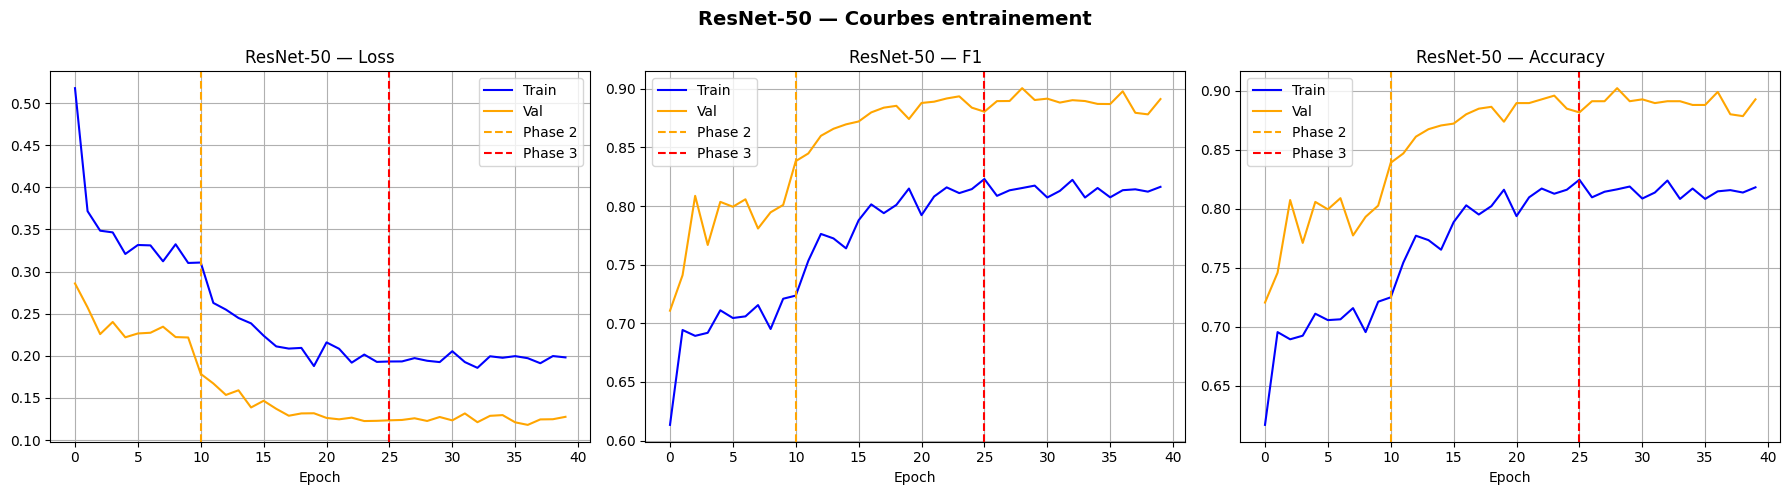

In [8]:
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super().__init__()
        
        # ── Backbone ResNet-50 ──
        self.backbone = timm.create_model(
            'resnet50',          # ← ResNet-50
            pretrained  = pretrained,
            num_classes = 0,
            global_pool = 'avg'
        )
        
        in_features = self.backbone.num_features  # 2048
        
        # ── Custom Head ──
        self.head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        return self.head(self.backbone(x))
    
    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
        print("Backbone gele")
    
    def unfreeze_last_blocks(self, n=2):
        # ResNet a des layers nommés
        layers = [
            self.backbone.layer4,
            self.backbone.layer3
        ]
        for layer in layers[:n]:
            for p in layer.parameters():
                p.requires_grad = True
        print(f"Derniers {n} blocs degeles")
    
    def unfreeze_all(self):
        for p in self.backbone.parameters():
            p.requires_grad = True
        print("Backbone entier degele")

# ── Créer modèle ──
model_resnet = ResNet50Classifier(
    num_classes=NUM_CLASSES,
    pretrained =True
).to(device)

total     = sum(p.numel() for p in model_resnet.parameters())
trainable = sum(p.numel() for p in model_resnet.parameters()
                if p.requires_grad)
print(f"\n✅ ResNet-50 créé :")
print(f"   Total params    : {total:,}")
print(f"   Trainable params: {trainable:,}")

class FocalLoss(nn.Module):
    def __init__(self, gamma=2, weight=None):
        super().__init__()
        self.gamma = gamma
        self.ce    = nn.CrossEntropyLoss(
            weight   =weight,
            reduction='none'
        )

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt      = torch.exp(-ce_loss)
        focal   = ((1 - pt) ** self.gamma) * ce_loss
        return focal.mean()

print("✅ Focal Loss definie")

def train_model(model, train_loader, val_loader,
                class_weights, device, epochs=40):

    criterion = FocalLoss(gamma=2, weight=class_weights)
    model.freeze_backbone()
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad,
               model.parameters()),
        lr=1e-3
    )
    scheduler = None

    history = {
        'train_loss': [], 'val_loss': [],
        'train_f1'  : [], 'val_f1'  : [],
        'train_acc' : [], 'val_acc' : []
    }

    best_f1    = 0
    best_epoch = 0

    for epoch in range(epochs):

        # ── Phases ──
        if epoch == 10:
            print("\n" + "="*50)
            model.unfreeze_last_blocks(n=2)
            optimizer = torch.optim.AdamW(
                model.parameters(), lr=5e-5
            )
            scheduler = torch.optim.lr_scheduler\
                .CosineAnnealingLR(optimizer, T_max=15)
            print("="*50)

        if epoch == 25:
            print("\n" + "="*50)
            model.unfreeze_all()
            optimizer = torch.optim.AdamW(
                model.parameters(), lr=1e-6
            )
            scheduler = torch.optim.lr_scheduler\
                .CosineAnnealingLR(optimizer, T_max=15)
            print("="*50)

        # ── Train ──
        model.train()
        train_loss  = 0
        train_preds = []
        train_true  = []

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            preds = outputs.argmax(dim=1).cpu().numpy()
            train_preds.extend(preds)
            train_true.extend(labels.cpu().numpy())

        # ── Validation ──
        model.eval()
        val_loss  = 0
        val_preds = []
        val_true  = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)
                val_loss += loss.item()
                preds = outputs.argmax(dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_true.extend(labels.cpu().numpy())

        # ── Métriques ──
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss   = val_loss   / len(val_loader)

        train_f1  = f1_score(train_true, train_preds,
                              average='macro',
                              zero_division=0)
        val_f1    = f1_score(val_true, val_preds,
                              average='macro',
                              zero_division=0)
        train_acc = np.mean(
            np.array(train_preds) == np.array(train_true)
        )
        val_acc   = np.mean(
            np.array(val_preds) == np.array(val_true)
        )

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Loss: {avg_train_loss:.4f}/{avg_val_loss:.4f} | "
              f"F1: {train_f1:.4f}/{val_f1:.4f} | "
              f"Acc: {train_acc:.4f}/{val_acc:.4f}")

        if val_f1 > best_f1:
            best_f1    = val_f1
            best_epoch = epoch + 1
            torch.save(model_resnet.state_dict(),
                       'best_model_resnet.pth')  # ← nom différent
            print(f"  Modele sauvegarde "
                  f"(F1={best_f1:.4f} Acc={val_acc:.4f})")

        if scheduler is not None:
            scheduler.step()

    print(f"\n✅ Entrainement termine !")
    print(f"   Meilleur F1    : {best_f1:.4f}")
    print(f"   Meilleure Epoch: {best_epoch}")

    return history

history_resnet = train_model(
    model        = model_resnet,
    train_loader = train_loader,
    val_loader   = val_loader,
    class_weights= class_weights,
    device       = device,
    epochs       = EPOCHS
)

# ── Courbes ResNet ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_resnet['train_loss'],
             label='Train', color='blue')
axes[0].plot(history_resnet['val_loss'],
             label='Val',   color='orange')
axes[0].set_title("ResNet-50 — Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_resnet['train_f1'],
             label='Train', color='blue')
axes[1].plot(history_resnet['val_f1'],
             label='Val',   color='orange')
axes[1].set_title("ResNet-50 — F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history_resnet['train_acc'],
             label='Train', color='blue')
axes[2].plot(history_resnet['val_acc'],
             label='Val',   color='orange')
axes[2].set_title("ResNet-50 — Accuracy")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True)

for ax in axes:
    ax.axvline(x=10, color='orange',
                linestyle='--', label='Phase 2')
    ax.axvline(x=25, color='red',
                linestyle='--', label='Phase 3')
    ax.legend()

plt.suptitle("ResNet-50 — Courbes entrainement",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

         COMPARAISON EFFICIENTNET-B4 vs RESNET-50
Métrique                  EfficientNet-B4       ResNet-50
------------------------------------------------------------
Meilleur F1                        0.8426          0.9006
Meilleure Accuracy                 0.8420          0.9021
Total Params                          19M             25M
Epochs                                 40              40


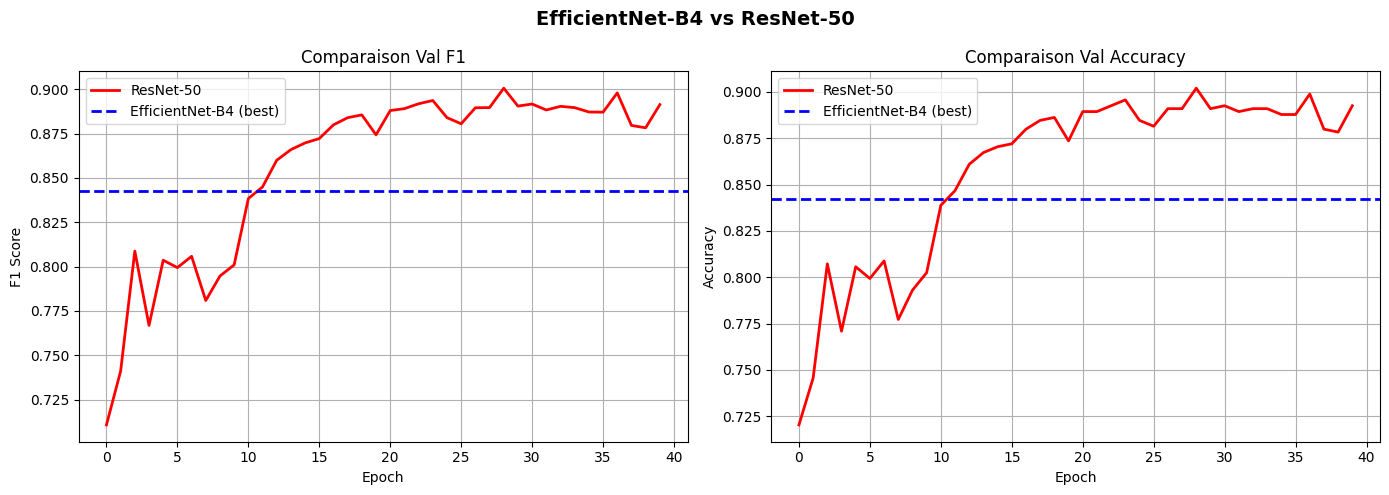

In [9]:
# ── Tableau comparaison ──
print("=" * 60)
print("         COMPARAISON EFFICIENTNET-B4 vs RESNET-50")
print("=" * 60)
print(f"{'Métrique':<25} {'EfficientNet-B4':>15} {'ResNet-50':>15}")
print("-" * 60)
print(f"{'Meilleur F1':<25} {'0.8426':>15} {max(history_resnet['val_f1']):>15.4f}")
print(f"{'Meilleure Accuracy':<25} {'0.8420':>15} {max(history_resnet['val_acc']):>15.4f}")
print(f"{'Total Params':<25} {'19M':>15} {'25M':>15}")
print(f"{'Epochs':<25} {'40':>15} {'40':>15}")
print("=" * 60)

# ── Courbes comparaison ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 comparaison
axes[0].plot(history_resnet['val_f1'],
             label='ResNet-50',
             color='red', linewidth=2)
axes[0].axhline(y=0.8426, color='blue',
                 linewidth=2,
                 linestyle='--',
                 label='EfficientNet-B4 (best)')
axes[0].set_title("Comparaison Val F1")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("F1 Score")
axes[0].legend()
axes[0].grid(True)

# Accuracy comparaison
axes[1].plot(history_resnet['val_acc'],
             label='ResNet-50',
             color='red', linewidth=2)
axes[1].axhline(y=0.8420, color='blue',
                 linewidth=2,
                 linestyle='--',
                 label='EfficientNet-B4 (best)')
axes[1].set_title("Comparaison Val Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("EfficientNet-B4 vs ResNet-50",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



  EfficientNet-B4 — Test Set
  Accuracy : 79.15%
  F1 Macro : 79.32%

  ResNet-50 — Test Set
  Accuracy : 86.10%
  F1 Macro : 85.97%


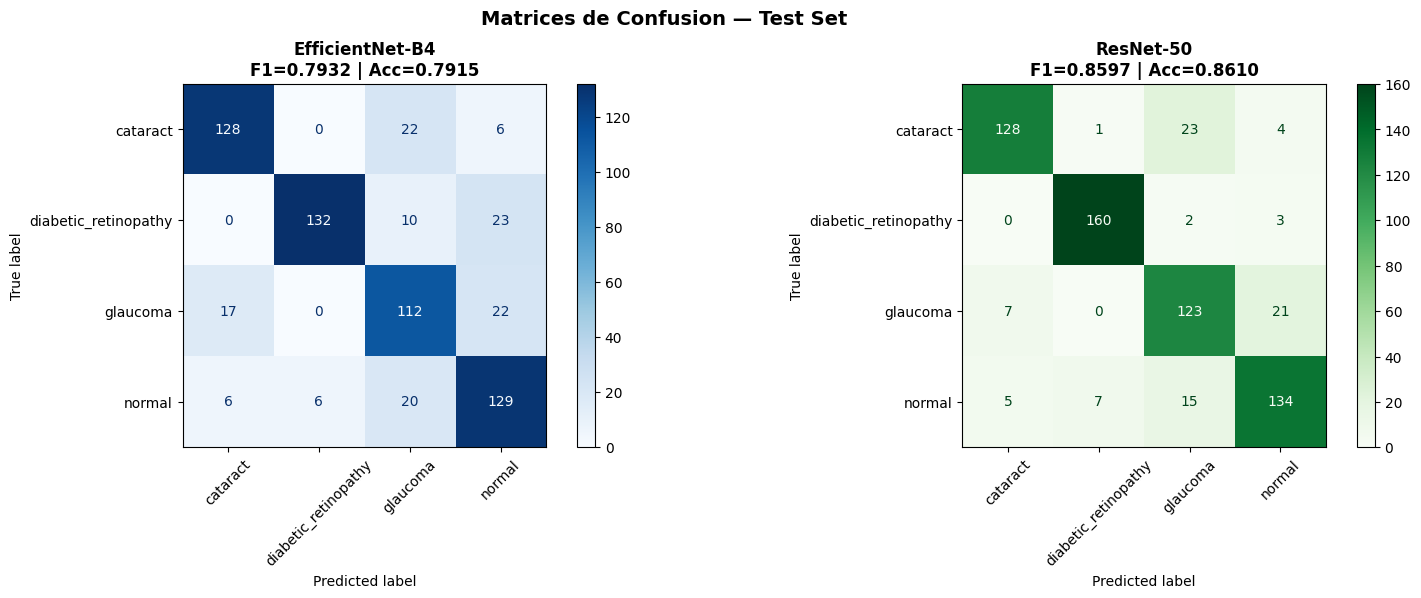

  EfficientNet-B4 — Rapport
                      precision    recall  f1-score   support

            cataract       0.85      0.82      0.83       156
diabetic_retinopathy       0.96      0.80      0.87       165
            glaucoma       0.68      0.74      0.71       151
              normal       0.72      0.80      0.76       161

            accuracy                           0.79       633
           macro avg       0.80      0.79      0.79       633
        weighted avg       0.80      0.79      0.79       633

  ResNet-50 — Rapport
                      precision    recall  f1-score   support

            cataract       0.91      0.82      0.86       156
diabetic_retinopathy       0.95      0.97      0.96       165
            glaucoma       0.75      0.81      0.78       151
              normal       0.83      0.83      0.83       161

            accuracy                           0.86       633
           macro avg       0.86      0.86      0.86       633
        weighte

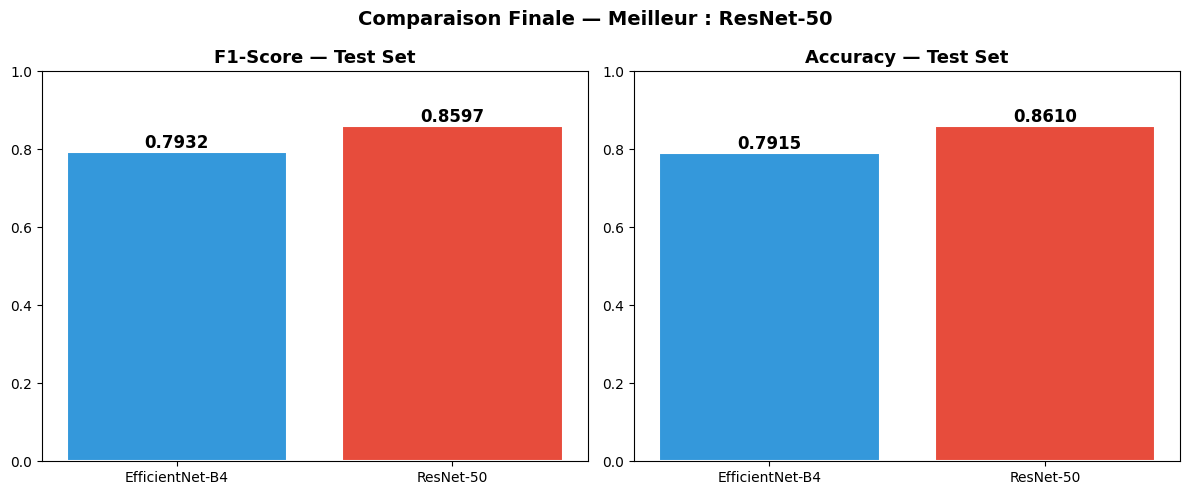

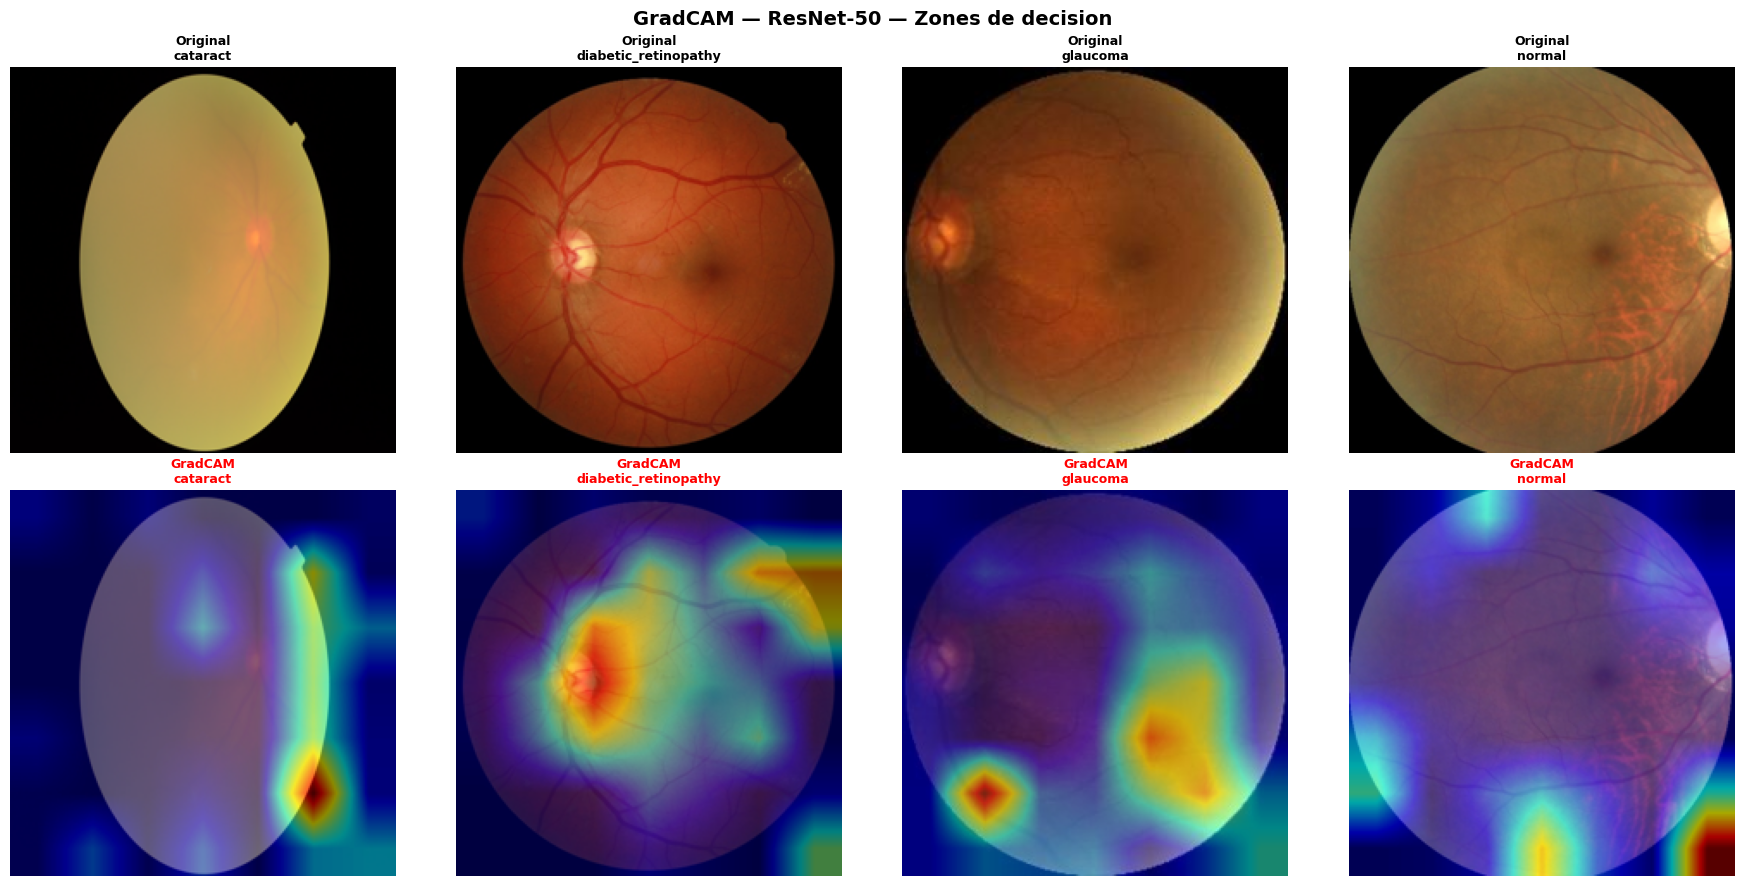


✅ Evaluation complete !
   Modele final : ResNet-50
   F1  Test     : 85.97%
   Acc Test     : 86.10%


In [10]:
class_names  = ['cataract', 'diabetic_retinopathy',
                'glaucoma', 'normal']

# ════════════════════
# 1 — Evaluation Test Set
# ════════════════════
def evaluate_model(model, test_loader, device, model_name):
    model.eval()
    all_preds  = []
    all_labels = []
    with torch.no_grad():
        for images, labels in test_loader:
            images  = images.to(device)
            outputs = model(images)
            preds   = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds,
                    average='macro', zero_division=0)
    print(f"\n{'='*45}")
    print(f"  {model_name} — Test Set")
    print(f"{'='*45}")
    print(f"  Accuracy : {acc*100:.2f}%")
    print(f"  F1 Macro : {f1*100:.2f}%")
    print(f"{'='*45}")
    return all_preds, all_labels, acc, f1

preds_eff, labels_eff, acc_eff, f1_eff = evaluate_model(
    model,        test_loader, device, "EfficientNet-B4"
)
preds_res, labels_res, acc_res, f1_res = evaluate_model(
    model_resnet, test_loader, device, "ResNet-50"
)

# ════════════════════
# 2 — Matrices de Confusion
# ════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_eff = confusion_matrix(labels_eff, preds_eff)
ConfusionMatrixDisplay(
    cm_eff, display_labels=class_names
).plot(ax=axes[0], cmap='Blues', xticks_rotation=45)
axes[0].set_title(
    f"EfficientNet-B4\nF1={f1_eff:.4f} | Acc={acc_eff:.4f}",
    fontsize=12, fontweight='bold'
)

cm_res = confusion_matrix(labels_res, preds_res)
ConfusionMatrixDisplay(
    cm_res, display_labels=class_names
).plot(ax=axes[1], cmap='Greens', xticks_rotation=45)
axes[1].set_title(
    f"ResNet-50\nF1={f1_res:.4f} | Acc={acc_res:.4f}",
    fontsize=12, fontweight='bold'
)

plt.suptitle("Matrices de Confusion — Test Set",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ════════════════════
# 3 — Rapport Classification
# ════════════════════
print("="*55)
print("  EfficientNet-B4 — Rapport")
print("="*55)
print(classification_report(
    labels_eff, preds_eff,
    target_names=class_names,
    zero_division=0
))

print("="*55)
print("  ResNet-50 — Rapport")
print("="*55)
print(classification_report(
    labels_res, preds_res,
    target_names=class_names,
    zero_division=0
))

# ════════════════════
# 4 — Comparaison Bar Chart
# ════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models    = ['EfficientNet-B4', 'ResNet-50']
f1_scores = [f1_eff,  f1_res]
accs      = [acc_eff, acc_res]
colors    = ['#3498DB', '#E74C3C']

bars1 = axes[0].bar(models, f1_scores,
                     color=colors,
                     edgecolor='white',
                     linewidth=1.5)
axes[0].set_title("F1-Score — Test Set",
                   fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars1, f1_scores):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.4f}', ha='center',
        fontsize=12, fontweight='bold'
    )

bars2 = axes[1].bar(models, accs,
                     color=colors,
                     edgecolor='white',
                     linewidth=1.5)
axes[1].set_title("Accuracy — Test Set",
                   fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars2, accs):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.4f}', ha='center',
        fontsize=12, fontweight='bold'
    )

winner = "ResNet-50" if f1_res > f1_eff else "EfficientNet-B4"
plt.suptitle(f"Comparaison Finale — Meilleur : {winner}",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ════════════════════
# 5 — GradCAM (ResNet-50)
# ════════════════════
target_layers = [model_resnet.backbone.layer4[-1]]
cam = GradCAM(model=model_resnet,
               target_layers=target_layers)

transform_gradcam = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std= [0.229, 0.224, 0.225]
    )
])

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, cls in enumerate(class_names):
    cls_path = f"{DATASET_PATH}/{cls}"
    img_file = os.listdir(cls_path)[5]
    img      = Image.open(f"{cls_path}/{img_file}").convert('RGB')
    img_224  = img.resize((224, 224))
    img_arr  = np.array(img_224) / 255.0

    input_tensor  = transform_gradcam(img).unsqueeze(0)
    grayscale_cam = cam(input_tensor=input_tensor)[0]
    visualization = show_cam_on_image(
        img_arr.astype(np.float32),
        grayscale_cam,
        use_rgb=True
    )

    axes[0][i].imshow(img_224)
    axes[0][i].set_title(f"Original\n{cls}",
                          fontsize=9, fontweight='bold')
    axes[0][i].axis('off')

    axes[1][i].imshow(visualization)
    axes[1][i].set_title(f"GradCAM\n{cls}",
                          fontsize=9,
                          color='red',
                          fontweight='bold')
    axes[1][i].axis('off')

plt.suptitle(
    "GradCAM — ResNet-50 — Zones de decision",
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("\n✅ Evaluation complete !")
print(f"   Modele final : {winner}")
print(f"   F1  Test     : {f1_res*100:.2f}%")
print(f"   Acc Test     : {acc_res*100:.2f}%")
